# PAPI - Phân tích khám phá

Notebook này trình bày phân tích khám phá nhằm rút ra các phát hiện chính, làm cơ sở để nhóm xác định bốn mục tiêu phân tích cho dashboard.

Notebook chỉ đọc dữ liệu từ thư mục data/processed và không chỉnh sửa dữ liệu. Notebook được chạy sau preprocessing.ipynb.

In [1]:
import sys, os
ROOT = os.path.dirname(os.getcwd())  # tu notebooks/ len thu muc goc
sys.path.insert(0, os.path.join(ROOT, 'src'))
import pandas as pd
pd.set_option('display.max_columns', 30, 'display.width', 160)
RAW = os.path.join(ROOT, 'data', 'raw'); PROC = os.path.join(ROOT, 'data', 'processed')
import matplotlib
import matplotlib.pyplot as plt, seaborn as sns
get_ipython().run_line_magic('matplotlib', 'inline')
sns.set_theme(style='whitegrid'); plt.rcParams['font.family'] = 'DejaVu Sans'
fact = pd.read_parquet(os.path.join(PROC, 'fact_papi_long.parquet'))
wide = pd.read_parquet(os.path.join(PROC, 'agg_province_year.parquet'))
nat  = pd.read_parquet(os.path.join(PROC, 'agg_national_year.parquet'))
ind  = pd.read_csv(os.path.join(PROC, 'dim_indicator.csv'))
NAME = dict(zip(ind.code, ind.short)); ORDER = [f'D{i}' for i in range(1, 9)]
FIGDIR = os.path.join(ROOT, 'reports', 'figures'); os.makedirs(FIGDIR, exist_ok=True)
print('fact', fact.shape, '| wide', wide.shape)

fact (6094, 4) | wide (882, 18)


## 1. Chất lượng và độ phủ dữ liệu

In [2]:
print('Số tỉnh-năm có tổng hợp lệ:', wide.total_papi.notna().sum(), '/ 882')
wide[wide.total_papi.isna()].groupby('year').size()

Số tỉnh-năm có tổng hợp lệ: 869 / 882


year
2014    2
2018    2
2021    3
2022    2
2023    2
2024    2
dtype: int64

**Nhận xét.** Có 13 trên 882 tỉnh-năm thiếu dữ liệu, chiếm khoảng 1,5 phần trăm, tập trung ở các năm 2014, 2018 và 2021-2024. Mức độ đầy đủ này đủ để tiến hành các phân tích tiếp theo.

## 2. Phân tích đơn biến

code
Tham gia            5.09
Minh bạch           5.47
Giải trình          5.02
Chống tham nhũng    6.38
Thủ tục HC          7.12
Dịch vụ công        7.15
Môi trường          3.70
QT điện tử          3.10
Name: score, dtype: float32

/var/folders/b3/3q9v57452ns2d6kyxgcfs3h00000gn/T/ipykernel_45030/2653185990.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NAME[c] for c in ORDER], rotation=25)


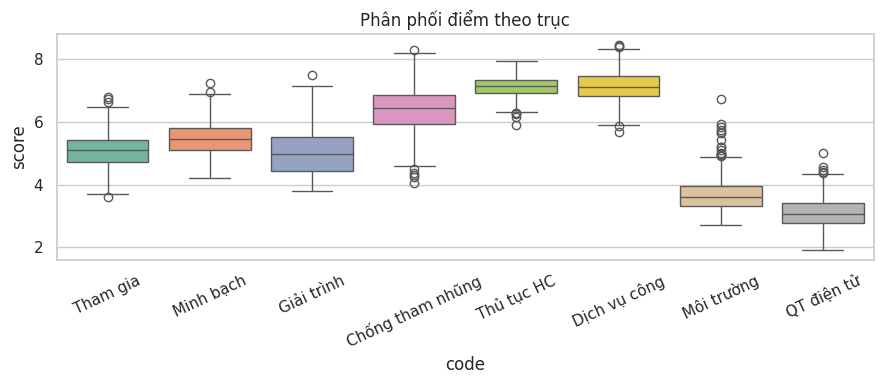

In [3]:
dm = fact.groupby('code', observed=True)['score'].mean().reindex(ORDER)
display(dm.round(2).rename(NAME))
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=fact, x='code', y='score', order=ORDER, hue='code', legend=False, palette='Set2', ax=ax)
ax.set_xticklabels([NAME[c] for c in ORDER], rotation=25)
ax.set_title('Phân phối điểm theo trục'); plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'eda_box.png'), dpi=110, bbox_inches='tight'); plt.show()

**Nhận xét.** Điểm trung bình cao nhất thuộc về Cung ứng dịch vụ công (7,15) và Thủ tục hành chính (7,12); thấp nhất là Quản trị điện tử (3,10) và Quản trị môi trường (3,70). Hai trục có điểm thấp nhất cũng là hai trục được bổ sung muộn nhất, từ năm 2018.

## 3. Phân tích theo thời gian

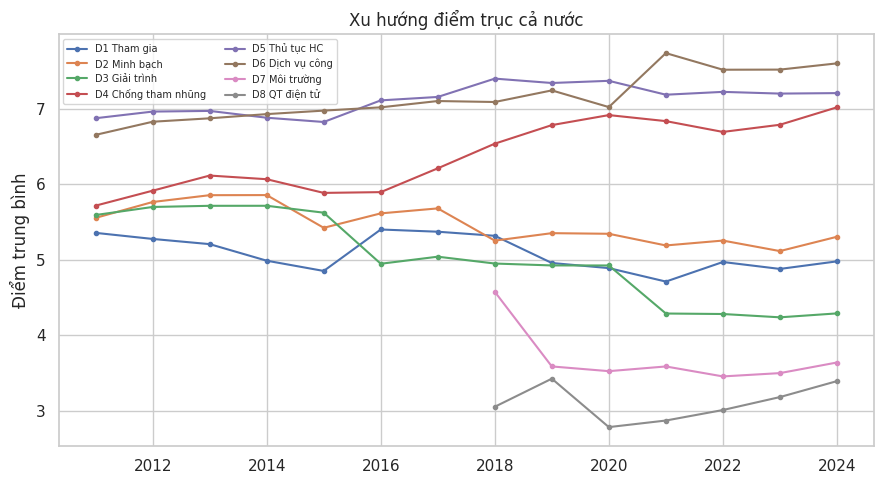

In [4]:
piv = nat.pivot(index='year', columns='code', values='mean_score')
fig, ax = plt.subplots(figsize=(9, 5))
for c in ORDER:
    s = piv[c].dropna(); ax.plot(s.index, s.values, marker='o', ms=3, label=f'{c} {NAME[c]}')
ax.legend(fontsize=7, ncol=2); ax.set_title('Xu hướng điểm trục cả nước'); ax.set_ylabel('Điểm trung bình')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'eda_trend.png'), dpi=110, bbox_inches='tight'); plt.show()

**Nhận xét.** Kiểm soát tham nhũng và Cung ứng dịch vụ công có xu hướng tăng trong cả giai đoạn; trong khi Trách nhiệm giải trình, Quản trị môi trường và Tham gia có xu hướng giảm. Cần lưu ý về phương pháp: mức tăng đột biến tại năm 2018 phản ánh việc bổ sung hai trục D7 và D8, không phản ánh thay đổi thực chất, do đó không nên so sánh tổng điểm PAPI vắt qua mốc 2018.

## 4. Phân tích theo không gian (năm 2024)

,province_vi,total_papi,rank_year
836,Quảng Ninh,47.821236,1
864,Tây Ninh,47.345245,2
857,Bình Thuận,47.126648,3
825,Thái Nguyên,46.348648,4
856,Ninh Thuận,45.732285,5


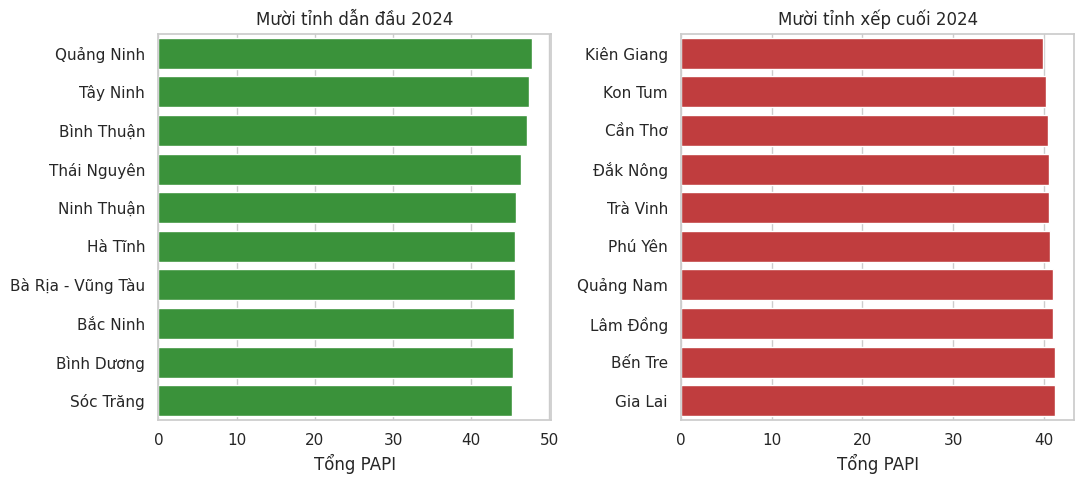

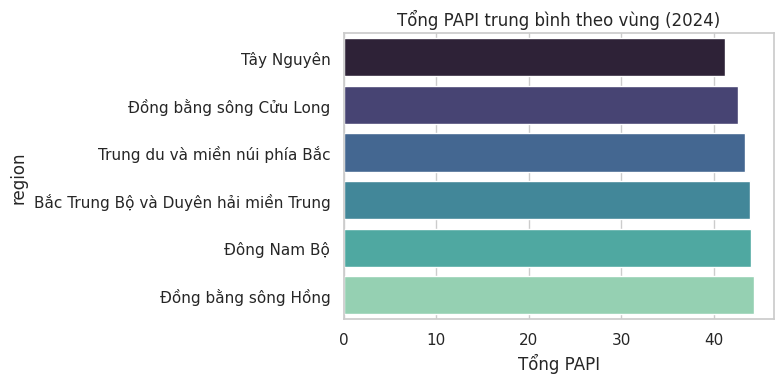

In [5]:
w24 = wide[(wide.year == 2024) & wide.total_papi.notna()]
display(w24.nlargest(5, 'total_papi')[['province_vi', 'total_papi', 'rank_year']])
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
t = w24.nlargest(10, 'total_papi'); b = w24.nsmallest(10, 'total_papi')
sns.barplot(data=t, y='province_vi', x='total_papi', color='#2ca02c', ax=ax[0]); ax[0].set_title('Mười tỉnh dẫn đầu 2024')
sns.barplot(data=b, y='province_vi', x='total_papi', color='#d62728', ax=ax[1]); ax[1].set_title('Mười tỉnh xếp cuối 2024')
for a in ax: a.set_xlabel('Tổng PAPI'); a.set_ylabel('')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'eda_topbottom.png'), dpi=110, bbox_inches='tight'); plt.show()
rr = w24.groupby('region')['total_papi'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=rr.values, y=rr.index, hue=rr.index, legend=False, palette='mako', ax=ax)
ax.set_title('Tổng PAPI trung bình theo vùng (2024)'); ax.set_xlabel('Tổng PAPI')
plt.tight_layout(); plt.savefig(os.path.join(FIGDIR, 'eda_region.png'), dpi=110, bbox_inches='tight'); plt.show()

**Nhận xét.** Năm 2024, Quảng Ninh đứng đầu cả nước. Theo vùng, Đồng bằng sông Hồng và Đông Nam Bộ có điểm trung bình cao nhất, còn Tây Nguyên thấp nhất. Hà Tĩnh nằm trong nhóm mười tỉnh dẫn đầu ở cả mười năm có dữ liệu, thể hiện mức ổn định cao.

## 5. Phân tích đa biến

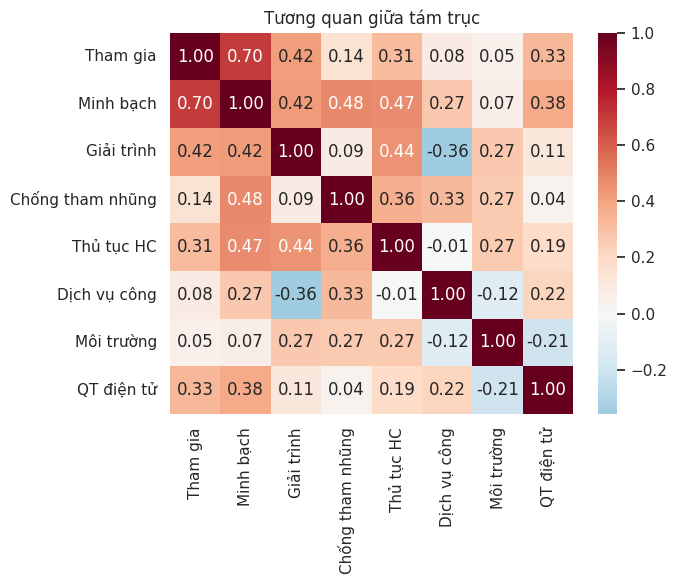

In [6]:
m = wide[wide.year >= 2018][ORDER].dropna()
cm = m.corr(); cm.index = [NAME[c] for c in cm.index]; cm.columns = [NAME[c] for c in cm.columns]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Tương quan giữa tám trục'); plt.tight_layout()
plt.savefig(os.path.join(FIGDIR, 'eda_corr.png'), dpi=110, bbox_inches='tight'); plt.show()

**Nhận xét.** Trục Công khai, minh bạch có hệ số tương quan cao với Tham gia (0,70), Kiểm soát tham nhũng (0,48) và Thủ tục hành chính (0,47), cho thấy đây có thể là một trục trung tâm trong quản trị cấp tỉnh.

## 6. Phát hiện điểm bất thường

In [7]:
w = wide.sort_values(['province_id', 'year']).copy()
w['d'] = w.groupby('province_id')['total_papi'].diff()
big = w.dropna(subset=['d']).reindex(w['d'].abs().sort_values(ascending=False).index)
display(big.head(4)[['province_vi', 'year', 'total_papi', 'd']])
wide[wide.rank_year <= 10].groupby('province_vi').size().sort_values(ascending=False).head(5)

,province_vi,year,total_papi,d
448,Lạng Sơn,2018.0,47.053329,12.089745
452,Lai Châu,2018.0,44.418747,11.322140
467,Nghệ An,2018.0,46.572361,10.818462
446,Yên Bái,2018.0,44.795937,10.419556


province_vi
Hà Tĩnh       10
Quảng Bình     9
Quảng Trị      8
Bắc Ninh       7
Nam Định       6
dtype: int64

**Nhận xét.** Các biến động lớn về tổng điểm đều rơi vào năm 2018, tương ứng với việc bổ sung hai trục, không phải biến động thực chất. Một số tỉnh như Hà Tĩnh, Quảng Bình và Quảng Trị duy trì thứ hạng cao ổn định qua nhiều năm.

## 7. Kết luận

Phân tích khám phá rút ra năm phát hiện chính, được trình bày chi tiết tại `docs/eda_findings.md`. Thứ nhất, người dân đánh giá cao nhóm trục về dịch vụ và thủ tục, nhưng đánh giá thấp hai trục mới là quản trị môi trường và quản trị điện tử. Thứ hai, nhóm trục liên quan đến phục vụ có xu hướng cải thiện, trong khi nhóm trục liên quan đến dân chủ cơ sở có xu hướng suy giảm. Thứ ba, trục công khai minh bạch giữ vai trò trung tâm. Thứ tư, kết quả phân hóa rõ giữa các vùng, với Tây Nguyên ở mức thấp nhất. Thứ năm, không nên so sánh tổng điểm PAPI vắt qua mốc năm 2018. Các phát hiện này là cơ sở để nhóm xác định bốn mục tiêu phân tích và thiết kế dashboard.